<a href="https://colab.research.google.com/github/SANTHIYAM306/mlops_training_tasks/blob/main/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


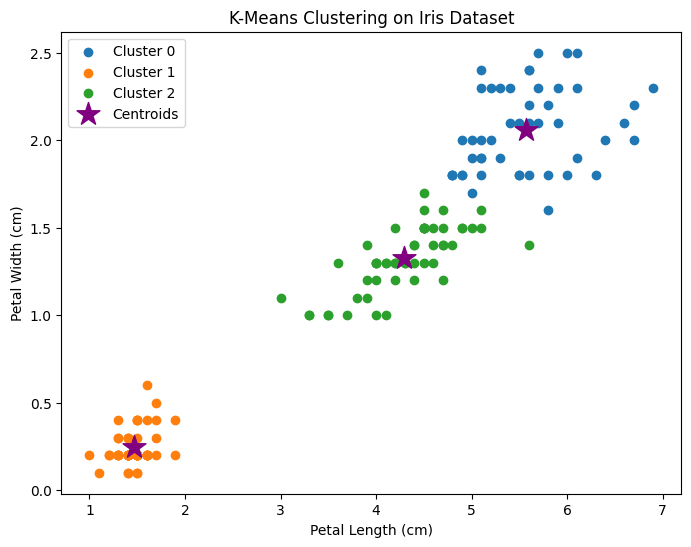

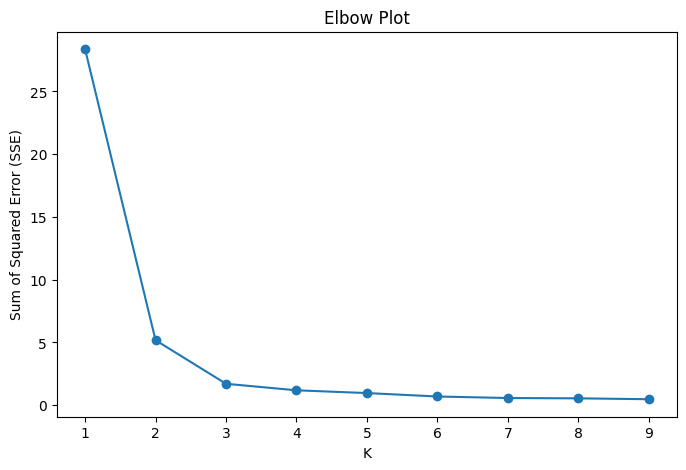

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Load Iris dataset
iris = load_iris()

# Create DataFrame with only petal length and petal width
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df = df[['petal length (cm)', 'petal width (cm)']]

print(df.head())

# ---------------------------------
# Step 1: Scale the data
# ---------------------------------
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

# ---------------------------------
# Step 2: Apply KMeans with 3 clusters
# ---------------------------------
km = KMeans(n_clusters=3, random_state=42)
y_pred = km.fit_predict(df_scaled)

# Add cluster labels
df['cluster'] = y_pred

# ---------------------------------
# Step 3: Plot clusters
# ---------------------------------
plt.figure(figsize=(8, 6))

for cluster in range(3):
    subset = df[df['cluster'] == cluster]
    plt.scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label=f'Cluster {cluster}'
    )

# Convert centroids back to original scale
centroids = scaler.inverse_transform(km.cluster_centers_)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='*',
    s=300,
    color='purple',
    label='Centroids'
)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('K-Means Clustering on Iris Dataset')
plt.legend()
plt.show()

# ---------------------------------
# Step 4: Elbow Plot
# ---------------------------------
sse = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), sse, marker='o')
plt.xlabel('K')
plt.ylabel('Sum of Squared Error (SSE)')
plt.title('Elbow Plot')
plt.show()